
# Chapter 8 — Economic Modeling (Part 1b: Climate feedbacks & sensitivity)

Continues Part 1 of Chapter 8 (see `chapter8_scoping.md` in the project
for the full roadmap). This notebook covers `chap8_physic3a-p.m` (16
scripts): the IPCC-style decomposition of the climate feedback parameter
$\lambda$ into its physical components (Planck, water-vapour/lapse-rate,
albedo, cloud, ...) with their assessed uncertainty, how that feedback
parameter sets both the ocean-atmosphere's radiative relaxation timescale
and the equilibrium climate sensitivity (ECS), and the IPCC AR6-style
effective-radiative-forcing bar chart.

Two custom functions the source calls, `pdfNormalRatio`/`cdfNormalRatio`
(the density/CDF of the ratio of two independent normal random
variables), are not present anywhere in the shipped `hfs-archive`
toolbox — reimplemented here from the standard closed-form ratio-of-
normals density (Hinkley, 1969; the uncorrelated case of the general
formula also known as Marsaglia's ratio distribution), which is a
textbook result, not an assumption.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_indigo  = np.array([ 75,   0, 130]) / 255
color_gold    = np.array([238, 201,   0]) / 255
color_darkorange = np.array([255, 140,   0]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_olive   = np.array([142, 142,  56]) / 255
color_darkgreen = np.array([  0, 100,   0]) / 255
color_salmon  = np.array([198, 113, 113]) / 255
color_maroon  = np.array([128,   0,   0]) / 255
color_black   = np.array([0, 0, 0])
color_matlab_darkyellow  = np.array([0.9290, 0.6940, 0.1250])
color_matlab_darkorange  = np.array([0.8500, 0.3250, 0.0980])
color_matlab_darkpurple  = np.array([0.4940, 0.1840, 0.5560])
color_matlab_mediumgreen = np.array([0.4660, 0.6740, 0.1880])
color_matlab_darkblue    = np.array([0, 0.4470, 0.7410])
color_matlab_darkred     = np.array([0.6350, 0.0780, 0.1840])

def pdf_normal_ratio(z, mu_x, sigma_x, mu_y, sigma_y):
    # Density of Z = X / Y at z, X ~ N(mu_x, sigma_x^2), Y ~ N(mu_y, sigma_y^2),
    # X and Y independent (Hinkley 1969 / Marsaglia ratio-of-normals density).
    z = np.asarray(z, dtype=float)
    a = np.sqrt((z / sigma_x) ** 2 + (1 / sigma_y) ** 2)
    b = (mu_x * z) / sigma_x**2 + mu_y / sigma_y**2
    c = (mu_x / sigma_x) ** 2 + (mu_y / sigma_y) ** 2
    d = np.exp((b**2 - c * a**2) / (2 * a**2))
    term1 = (b * d) / (a**3 * sigma_x * sigma_y * np.sqrt(2 * np.pi)) * (norm.cdf(b / a) - norm.cdf(-b / a))
    term2 = np.exp(-c / 2) / (np.pi * sigma_x * sigma_y * a**2)
    return term1 + term2

def cdf_normal_ratio(t, mu_x, sigma_x, mu_y, sigma_y, lower=0.0):
    t = np.atleast_1d(np.asarray(t, dtype=float))
    out = np.array([quad(pdf_normal_ratio, lower, ti, args=(mu_x, sigma_x, mu_y, sigma_y))[0] for ti in t])
    return out if out.size > 1 else out[0]



## 1. Individual feedback-parameter estimates

`chap8_physic3a.m`-`chap8_physic3c.m`. Three back-of-envelope estimates
of a feedback constant $\lambda$ (W/m^2/K): the emissivity feedback
implied by the single-layer greenhouse model, the ice-albedo feedback
implied by an observed change in planetary albedo per degree of warming,
and a combined total ($\lambda_0$ Planck + $\lambda_\alpha$ albedo +
$\lambda_\varepsilon$ water-vapour/cloud/lapse-rate) matching the
IPCC-style feedback decomposition used in the rest of this notebook.


In [2]:

epsilon, sigma = 0.78, 5.67e-8
T_s = 273.15 + 15
lam = -4 * (2 - epsilon) / 2 * sigma * T_s**3
print(f"Emissivity feedback: lambda = {lam:.4f} W/m^2/K")


Emissivity feedback: lambda = -3.3100 W/m^2/K


In [3]:

S0, d_alpha = 1368, -0.001023
lam = -1 / 4 * S0 * d_alpha
print(f"Albedo feedback (from d_alpha = {d_alpha}): lambda = {lam:.4f} W/m^2/K")

lam = 0.35
d_alpha = -4 * lam / S0
print(f"Implied d_alpha for lambda = {lam}: {1000 * d_alpha:.6f} (x1e-3)")


Albedo feedback (from d_alpha = -0.001023): lambda = 0.3499 W/m^2/K
Implied d_alpha for lambda = 0.35: -1.023392 (x1e-3)


In [4]:

lambda0 = -3.31           # Planck feedback
lambda_alpha = 0.35        # albedo feedback
lambda_epsilon = 1.85 - 0.50 + 2 / 3 * 0.42   # water vapour + lapse rate + cloud (illustrative combination)
print(f"lambda_epsilon = {lambda_epsilon:.4f}")
lam = lambda0 + lambda_alpha + lambda_epsilon
print(f"Total feedback: lambda = {lam:.4f} W/m^2/K")


lambda_epsilon = 1.6300
Total feedback: lambda = -1.3300 W/m^2/K



## 2. IPCC AR6-style feedback decomposition, with uncertainty

`chap8_physic3d.m`-`chap8_physic3h.m`. The IPCC AR6 assessment expresses
each physical feedback process as a normally-distributed estimate (mean
$\pm$ std. dev., W/m^2/K); independent feedbacks combine by summing means
and adding variances. This section works through the cloud-feedback
subcomponents, the non-Planck ("positive") feedback subcomponents, and
the resulting overall feedback-parameter distribution.


In [5]:

mu_cloud = np.array([0.20, 0.25, -0.20, 0.08, 0.12, 0.00])
sigma_cloud = np.array([0.10, 0.16, 0.20, 0.08, 0.12, 0.10])
mu_total_cloud = mu_cloud.sum()
sigma_total_cloud = np.sqrt((sigma_cloud**2).sum())
print(f"Total cloud feedback: mean = {mu_total_cloud:.2f}, std = {sigma_total_cloud:.4f}")

mu_feedback = np.array([-3.20, 1.15, 0.30, 0.45, 0.00, 0.00])
sigma_feedback = np.array([0.10, 0.15, 0.15, 0.33, 0.10, 0.15])
mu_climate_feedback = mu_feedback.sum()
sigma_climate_feedback = np.sqrt((sigma_feedback**2).sum())
print(f"Total climate feedback: mean = {mu_climate_feedback:.2f}, std = {sigma_climate_feedback:.4f}")


Total cloud feedback: mean = 0.45, std = 0.3262
Total climate feedback: mean = -1.30, std = 0.4432


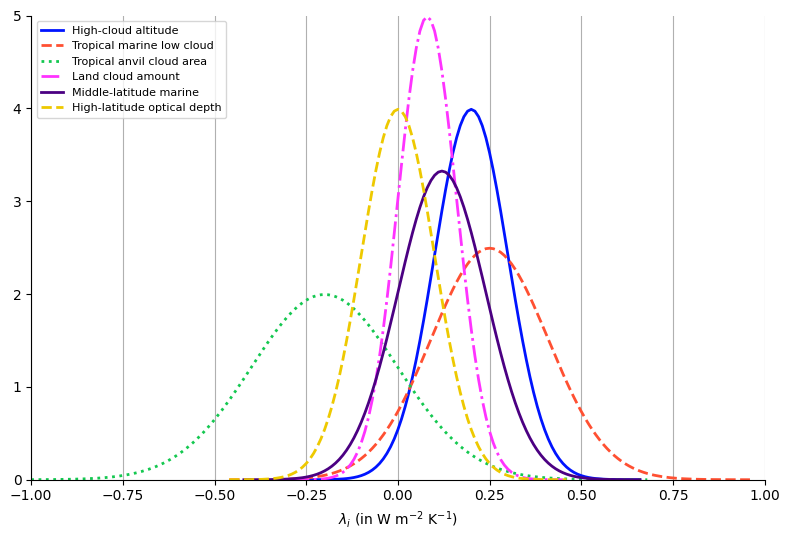

In [6]:

mu_cloud = np.array([0.20, 0.25, -0.20, 0.08, 0.12, 0.00])
sigma_cloud = np.array([0.10, 0.16, 0.20, 0.08, 0.12, 0.10])
labels_cloud = ["High-cloud altitude", "Tropical marine low cloud", "Tropical anvil cloud area",
                "Land cloud amount", "Middle-latitude marine", "High-latitude optical depth"]
colours = [color_blue, color_red, color_green, color_violet, color_indigo, color_gold]
styles = ["-", "--", ":", "-.", "-", "--"]

x = np.linspace(-1, 1, 201)

fig, ax = plt.subplots(figsize=(8, 5.5))
for i in range(6):
    y = norm.pdf(x, mu_cloud[i], sigma_cloud[i])
    y[np.abs(y) <= 1e-4] = np.nan
    ax.plot(x, y, styles[i], color=colours[i], linewidth=2.0, label=labels_cloud[i])
ax.set_xlabel(r"$\lambda_i$ (in W m$^{-2}$ K$^{-1}$)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, axis="x")
ax.set_xlim(-1, 1)
ax.set_xticks(np.arange(-1, 1.01, 0.25))
ax.set_ylim(0, 5)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


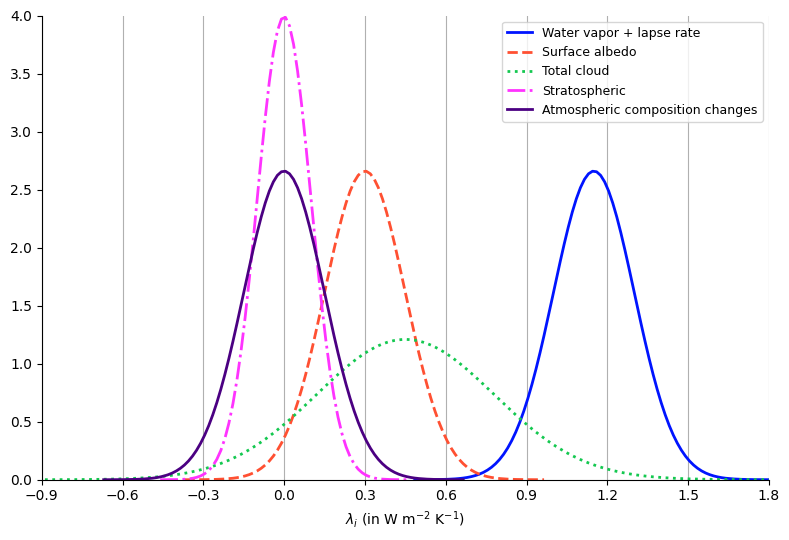

In [7]:

mu_feedback = np.array([1.15, 0.30, 0.45, 0.00, 0.00])
sigma_feedback = np.array([0.15, 0.15, 0.33, 0.10, 0.15])
labels_climate = ["Water vapor + lapse rate", "Surface albedo", "Total cloud",
                   "Stratospheric", "Atmospheric composition changes"]
colours = [color_blue, color_red, color_green, color_violet, color_indigo]
styles = ["-", "--", ":", "-.", "-"]

x = np.linspace(-1, 2, 201)

fig, ax = plt.subplots(figsize=(8, 5.5))
for i in range(5):
    y = norm.pdf(x, mu_feedback[i], sigma_feedback[i])
    y[np.abs(y) <= 1e-4] = np.nan
    ax.plot(x, y, styles[i], color=colours[i], linewidth=2.0, label=labels_climate[i])
ax.set_xlabel(r"$\lambda_i$ (in W m$^{-2}$ K$^{-1}$)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, axis="x")
ax.set_xlim(-0.9, 1.8)
ax.set_xticks(np.arange(-0.9, 1.81, 0.3))
ax.set_ylim(0, 4)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


Positive (non-Planck) feedback: mean = 1.90, std = 0.4317


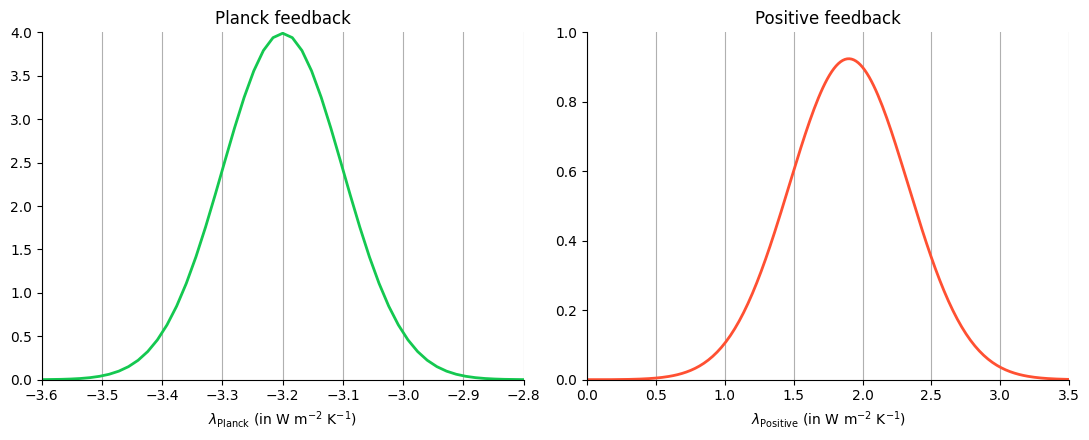

In [8]:

mu_feedback = np.array([-3.20, 1.15, 0.30, 0.45, 0.00, 0.00])
sigma_feedback = np.array([0.10, 0.15, 0.15, 0.33, 0.10, 0.15])

mu_negative, sigma_negative = mu_feedback[0], sigma_feedback[0]
mu_positive = mu_feedback[1:].sum()
sigma_positive = np.sqrt((sigma_feedback[1:]**2).sum())
print(f"Positive (non-Planck) feedback: mean = {mu_positive:.2f}, std = {sigma_positive:.4f}")

x1 = np.linspace(-4, 4, 501)
y1 = norm.pdf(x1, mu_negative, sigma_negative)
y1[np.abs(y1) <= 1e-7] = np.nan
y2 = norm.pdf(x1, mu_positive, sigma_positive)
y2[np.abs(y2) <= 1e-7] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(x1, y1, "-", color=color_green, linewidth=2.0)
axes[0].set_xlabel(r"$\lambda_{\mathrm{Planck}}$ (in W m$^{-2}$ K$^{-1}$)")
axes[0].set_title("Planck feedback")
axes[0].grid(True, axis="x")
axes[0].set_xlim(-3.6, -2.8)
axes[0].set_ylim(0, 4)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(x1, y2, "-", color=color_red, linewidth=2.0)
axes[1].set_xlabel(r"$\lambda_{\mathrm{Positive}}$ (in W m$^{-2}$ K$^{-1}$)")
axes[1].set_title("Positive feedback")
axes[1].grid(True, axis="x")
axes[1].set_xlim(0, 3.5)
axes[1].set_ylim(0, 1)
axes[1].spines[["top", "right"]].set_visible(False)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


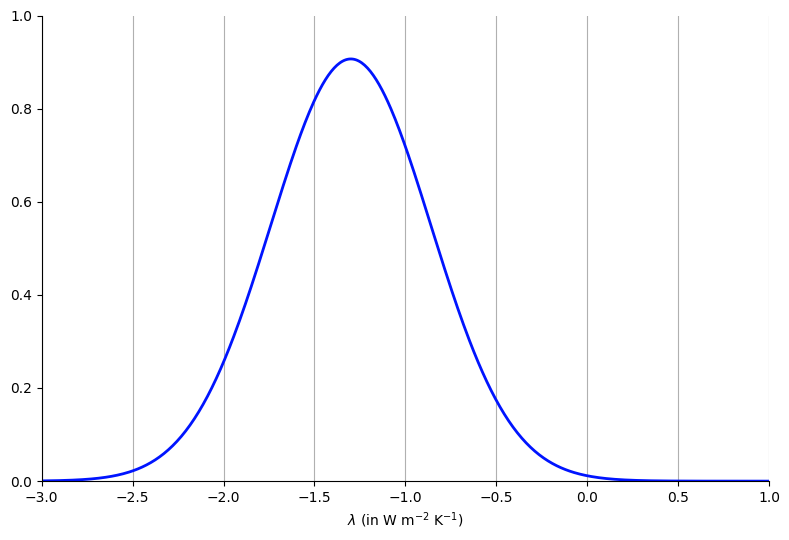

In [9]:

mu_feedback, sigma_feedback = -1.30, 0.44
x = np.linspace(-3, 1, 501)
y = norm.pdf(x, mu_feedback, sigma_feedback)
y[np.abs(y) <= 1e-7] = np.nan

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(x, y, "-", color=color_blue, linewidth=2.0)
ax.set_xlabel(r"$\lambda$ (in W m$^{-2}$ K$^{-1}$)")
ax.grid(True, axis="x")
ax.set_xlim(-3, 1)
ax.set_xticks(np.arange(-3, 1.01, 0.5))
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 3. Probability the total feedback is destabilizing

`chap8_physic3i.m`. Under $\lambda \sim N(-1.30, 0.44^2)$, the (small)
probability that the net feedback parameter is positive (a runaway,
destabilizing feedback).


In [10]:

mu_feedback, sigma_feedback = -1.30, 0.44
p = 1 - norm.cdf(-mu_feedback / sigma_feedback)
print(f"P(lambda > 0) = {100 * p:.2f}%")


P(lambda > 0) = 0.16%



## 4. Radiative relaxation time and equilibrium warming

`chap8_physic3j.m`. With an ocean heat capacity $c = 4\times10^8$
J/m^2/K and feedback parameter $\lambda = -1.33$ W/m^2/K, the system's
e-folding relaxation time and the resulting exponential approach to
equilibrium warming under a 4 W/m^2 forcing step.


tau = 300751879.70 s = 3480.92 days = 9.53 years
Half-life = 6.61 years


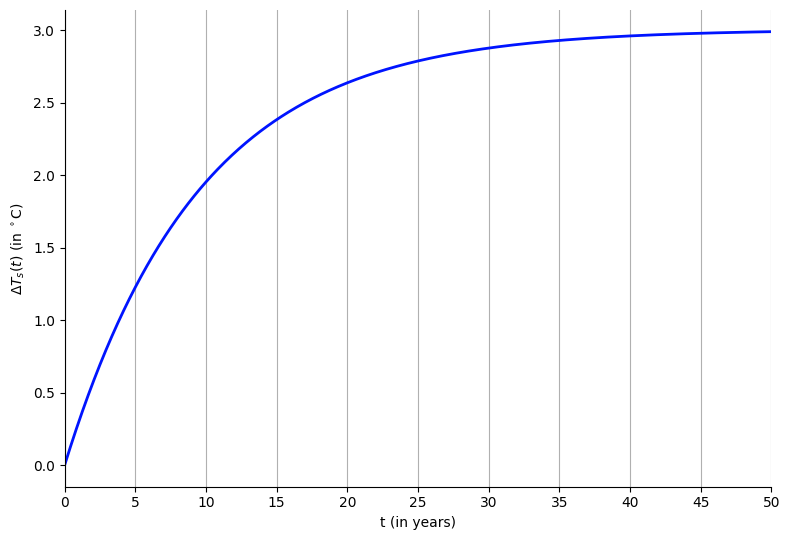

In [11]:

c = 4e8
lam = -1.33
tau_second = -c / lam
tau_day = tau_second / (24 * 3600)
tau_year = tau_day / 365.25
print(f"tau = {tau_second:.2f} s = {tau_day:.2f} days = {tau_year:.2f} years")
half_life = np.log(2) * tau_year
print(f"Half-life = {half_life:.2f} years")

t = np.linspace(0, 50, 12 * 50 + 1)
Delta_T0 = 0
Delta_T_star = 4 / 1.33
Delta_T = np.exp(-t / tau_year) * (Delta_T0 - Delta_T_star) + Delta_T_star

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(t, Delta_T, "-", color=color_blue, linewidth=2.0)
ax.set_xlabel("t (in years)")
ax.set_ylabel(r"$\Delta T_s(t)$ (in $^\circ$C)")
ax.grid(True, axis="x")
ax.set_xlim(0, 50)
ax.set_xticks(np.arange(0, 51, 5))
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 5. From feedback uncertainty to ECS uncertainty

`chap8_physic3k.m`-`chap8_physic3n.m`. Since equilibrium climate
sensitivity is $\mathrm{ECS} = \Delta F / (-\lambda)$, its distribution is
a *reciprocal-normal* transform of the feedback-parameter distribution —
heavier-tailed than the underlying normal, since $\lambda$ near zero maps
to arbitrarily large ECS. The same transform gives the relaxation-time
distribution, and a 50-member Monte Carlo ensemble shows the resulting
spread in the temperature-response trajectory.


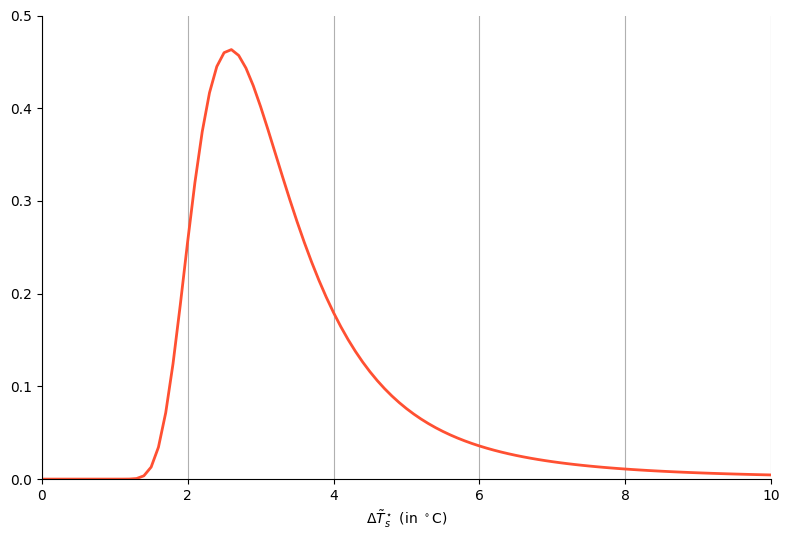

In [12]:

mu_lambda, sigma_lambda = -1.30, 0.44
Delta_F = 4
mu_xi = -mu_lambda / Delta_F
sigma_xi = sigma_lambda / Delta_F

def pdf_reciprocal_normal(x, mu_xi, sigma_xi):
    x = np.asarray(x, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return 1 / (x**2 * sigma_xi * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((1 / x - mu_xi) / sigma_xi) ** 2)

x = np.linspace(1e-6, 10, 101)
y = pdf_reciprocal_normal(x, mu_xi, sigma_xi)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(x, y, "-", color=color_red, linewidth=2.0)
ax.set_xlabel(r"$\Delta \tilde{T}_s^\star$ (in $^\circ$C)")
ax.grid(True, axis="x")
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.5)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


In [13]:

theta = np.arange(1, 11)
p = np.array([quad(pdf_reciprocal_normal, th, np.inf, args=(mu_xi, sigma_xi))[0] for th in theta])
print("theta:  ", np.round(theta, 2))
print("P(ECS > theta), %:", np.round(100 * p, 2))


theta:   [ 1  2  3  4  5  6  7  8  9 10]
P(ECS > theta), %: [99.84 94.26 52.86 24.61 12.63  7.35  4.73  3.3   2.44  1.88]


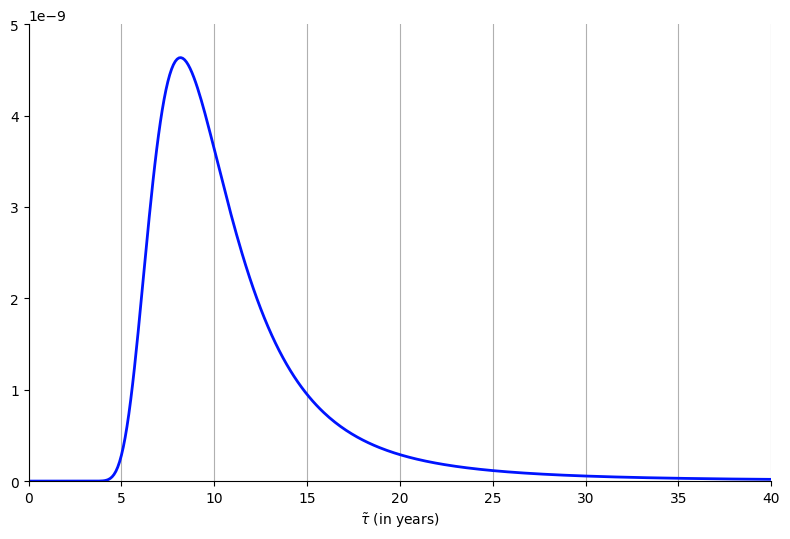

In [14]:

mu_xi_tau = -mu_lambda / c
sigma_xi_tau = sigma_lambda / c

tau_year_grid = np.linspace(0.1, 50.1, 501)
x_sec = tau_year_grid * 365.25 * 24 * 3600
y = pdf_reciprocal_normal(x_sec, mu_xi_tau, sigma_xi_tau)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(tau_year_grid, y, "-", color=color_blue, linewidth=2.0)
ax.set_xlabel(r"$\tilde{\tau}$ (in years)")
ax.grid(True, axis="x")
ax.set_xlim(0, 40)
ax.set_ylim(0, 5e-9)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


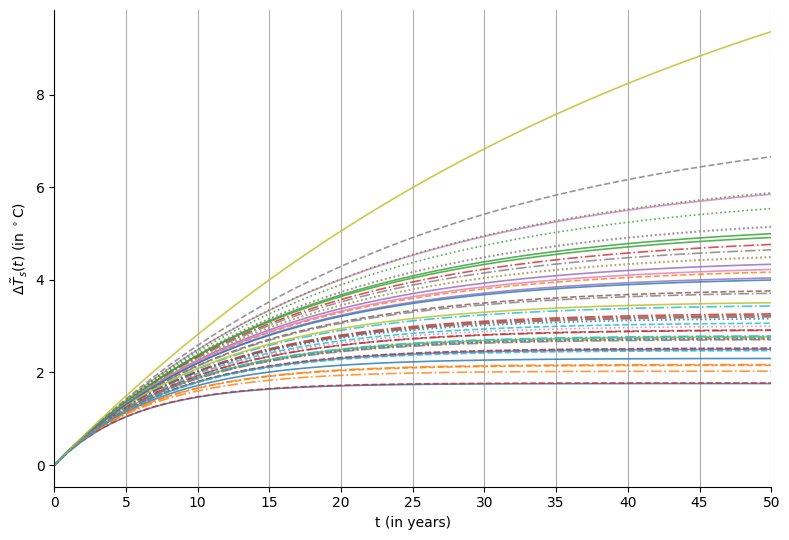

In [15]:

rng = np.random.default_rng(123)
nS = 50
lam_draws = mu_lambda + sigma_lambda * rng.standard_normal(nS)
tau_year_draws = (-c / lam_draws) / (24 * 3600) / 365.25
Delta_T_star_draws = -4 / lam_draws

t = np.concatenate([np.arange(0, 1.001, 0.10), np.arange(1, 51, 1)])
Delta_T = np.exp(-t[:, None] / tau_year_draws[None, :]) * (0 - Delta_T_star_draws[None, :]) + Delta_T_star_draws[None, :]

fig, ax = plt.subplots(figsize=(8, 5.5))
styles = ["-", "--", ":", "-."]
for i in range(nS):
    ax.plot(t, Delta_T[:, i], styles[i % 4], linewidth=1.2, alpha=0.8)
ax.set_xlabel("t (in years)")
ax.set_ylabel(r"$\Delta \tilde{T}_s(t)$ (in $^\circ$C)")
ax.grid(True, axis="x")
ax.set_xlim(0, 50)
ax.set_xticks(np.arange(0, 51, 5))
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 6. Effective radiative forcing since 1750 (IPCC AR6-style)

`chap8_physic3o.m`. The classic IPCC bar chart decomposing total
anthropogenic effective radiative forcing (W/m^2) into its components,
each with a 5-95% uncertainty range and central estimate.


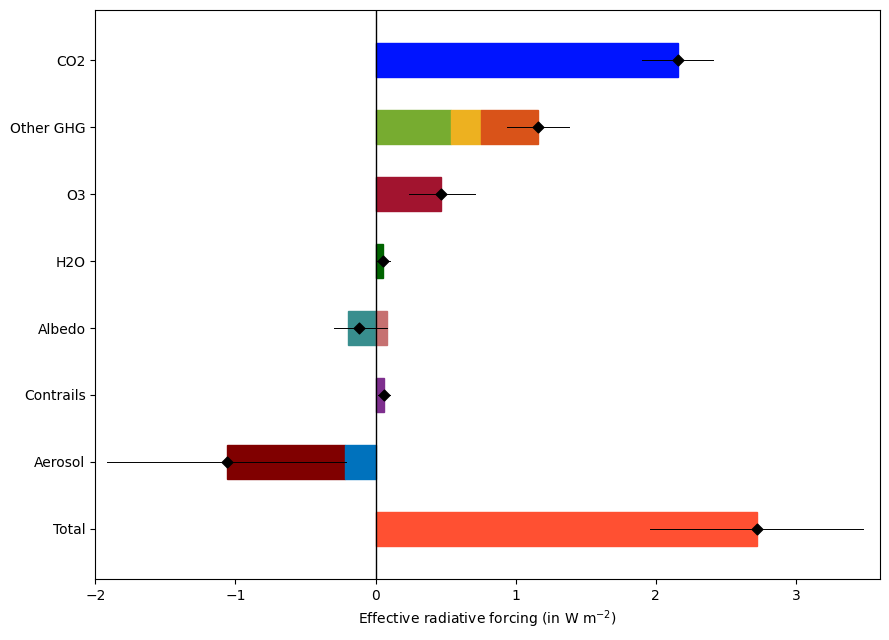

In [16]:

fig, ax = plt.subplots(figsize=(9, 6.5))

bars = [
    # (label, y, segments[(x0, width, color, sublabel, label_pos)])
    ("CO2",     8, [(0, 2.16, color_blue, None)]),
    ("Other GHG", 7, [(0, 0.54, color_matlab_mediumgreen, "CH4"),
                       (0.54, 0.21, color_matlab_darkyellow, "N2O"),
                       (0.75, 0.41, color_matlab_darkorange, "Halogens")]),
    ("O3",      6, [(0, 0.47, color_matlab_darkred, None)]),
    ("H2O",     5, [(0, 0.05, color_darkgreen, None)]),
    ("Albedo",  4, [(-0.20, 0.20, color_teal, "Land use"), (0, 0.08, color_salmon, "Snow-ice")]),
    ("Contrails", 3, [(0, 0.06, color_matlab_darkpurple, None)]),
    ("Aerosol", 2, [(-1.06, 0.84, color_maroon, "Cloud"), (-0.22, 0.22, color_matlab_darkblue, "Radiation")]),
    ("Total",   1, [(0, 2.72, color_red, None)]),
]

for label, y, segs in bars:
    for (x0, w, c, sub) in segs:
        ax.add_patch(plt.Rectangle((x0, y - 0.25), w, 0.5, facecolor=c, edgecolor=c))

x_interval = np.array([
    [1.90, 2.16, 2.41], [0.94, 1.16, 1.38], [0.24, 0.47, 0.71], [0.00, 0.05, 0.10],
    [-0.30, -0.12, 0.08], [0.02, 0.06, 0.10], [-1.92, -1.06, -0.21], [1.96, 2.72, 3.48],
])
for i in range(8):
    y = 8 - i
    ax.plot([x_interval[i, 0], x_interval[i, 2]], [y, y], "-", color="black", linewidth=0.7)
ax.scatter(x_interval[:, 1], np.arange(8, 0, -1), marker="D", s=30, color="black", zorder=5)

ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlabel(r"Effective radiative forcing (in W m$^{-2}$)")
ax.set_xlim(-2, 3.6)
ax.set_xticks(np.arange(-2, 3.6, 1))
ax.set_ylim(0.25, 8.75)
ax.set_yticks(range(1, 9))
ax.set_yticklabels(["Total", "Aerosol", "Contrails", "Albedo", "H2O", "O3", "Other GHG", "CO2"])
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 7. ECS under a stochastic forcing step

`chap8_physic3p.m`. If the forcing step itself is also uncertain
($\Delta F \sim N(4.00, 0.30^2)$ rather than a fixed 4 W/m^2), ECS becomes
the ratio of two independent normal random variables rather than a
reciprocal-normal transform of $\lambda$ alone — reimplemented via the
`pdf_normal_ratio`/`cdf_normal_ratio` helpers defined above.


ECS threshold:       [ 2.  3.  4.  5.  7. 10.]
P(ECS > threshold), %: [93.39 52.94 25.08 13.01  4.97  2.06]


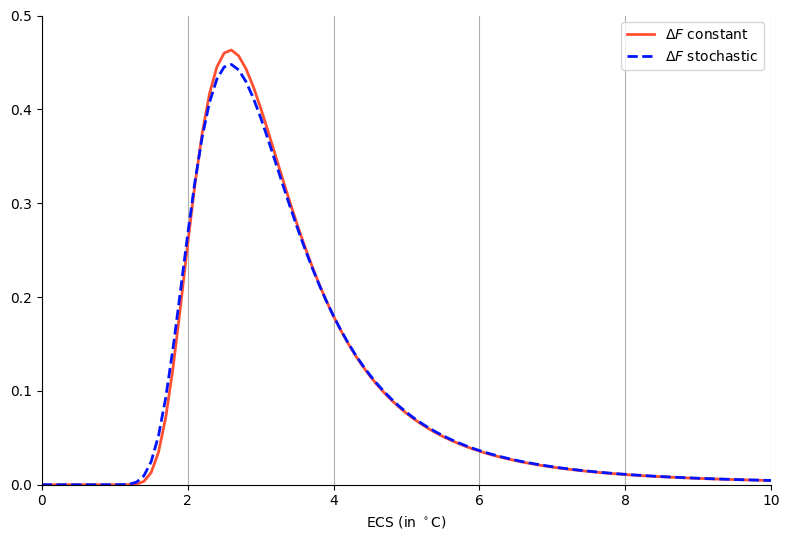

In [17]:

mu_lambda, sigma_lambda = -1.30, 0.44
mu_F, sigma_F = 4.00, 0.30

mu_xi = -mu_lambda / mu_F
sigma_xi = sigma_lambda / mu_F

x = np.linspace(1e-6, 10, 101)
y1 = pdf_reciprocal_normal(x, mu_xi, sigma_xi)
y2 = pdf_normal_ratio(x, -mu_F, sigma_F, mu_lambda, sigma_lambda)

t = np.array([2.0, 3.0, 4.0, 5.0, 7.0, 10.0])
z = 1 - cdf_normal_ratio(t, -mu_F, sigma_F, mu_lambda, sigma_lambda)
print("ECS threshold:      ", t)
print("P(ECS > threshold), %:", np.round(100 * z, 2))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(x, y1, "-", color=color_red, linewidth=2.0, label=r"$\Delta F$ constant")
ax.plot(x, y2, "--", color=color_blue, linewidth=2.0, label=r"$\Delta F$ stochastic")
ax.set_xlabel(r"ECS (in $^\circ$C)")
ax.legend(loc="upper right")
ax.grid(True, axis="x")
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.5)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## Summary

This notebook covers the 16 `chap8_physic3*.m` scripts: the IPCC-style
feedback-parameter decomposition, its propagation into equilibrium
climate sensitivity and the radiative relaxation timescale, and the
AR6-style effective-radiative-forcing bar chart. `pdf_normal_ratio` /
`cdf_normal_ratio` (Hinkley's closed-form ratio-of-normals density) are
tracked below as packaging candidates — this is a generic probability
primitive, not climate-specific, and Chapter 8's remaining physics
notebooks are likely to need it again for similar sensitivity/uncertainty
propagation exercises.

Continued in `08c_...` (planned: `chap8_physic4*.m`, `chap8_physic5*.m`).
